
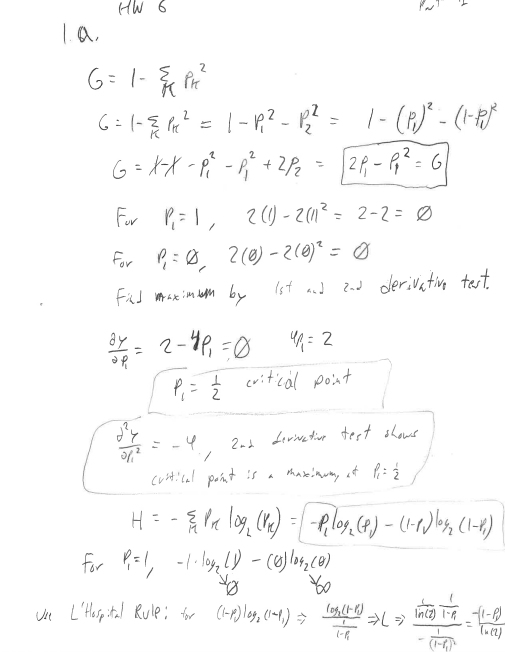





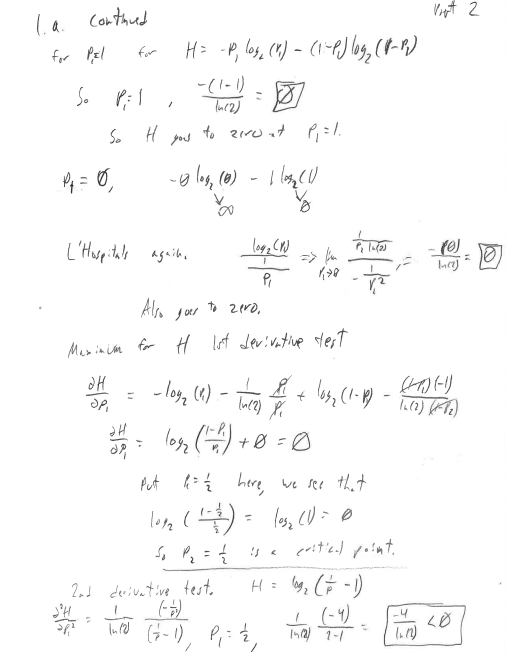

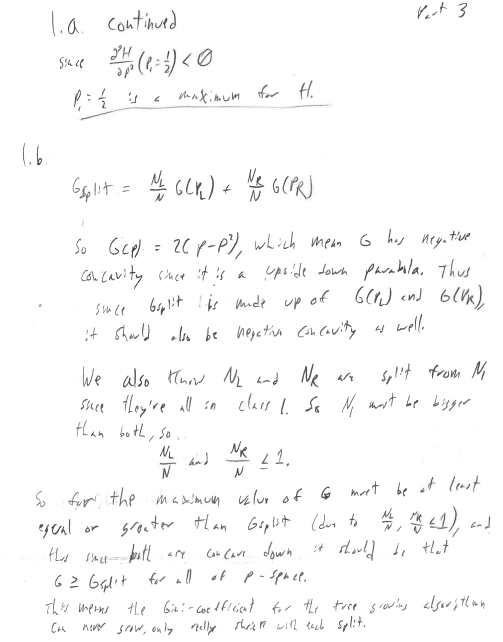

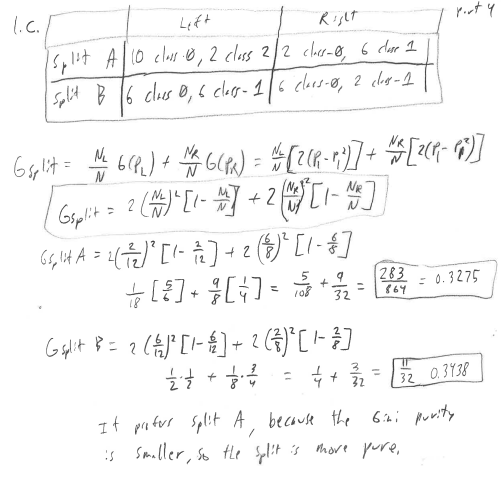

In [2]:
#Question 2
import numpy as np
import matplotlib.pyplot as plt
from sklearn .datasets import make_moons
RNG = np.random.default_rng(42)

X, y = make_moons(n_samples=300, noise=0.3, random_state=0)
X_test, y_test = X[0:210], y[0:210]
X_train, y_train = X[210:], y[210:]
#2.a Bootstrapping

def bootstrap(n_trees, X_train, y_train, X_test, y_test):

    trees = []
    fractions = []

    for b in range(n_trees):

        idx = RNG.choice(len(y_train), size=len(y_train), replace=True)
        frac = len(np.unique(idx)) / len(y_train)
        fractions.append(frac)
        X_boot, y_boot = X_train[idx], y_train[idx]
        
        #tree = DecisionTreeClassifier(max_features='sqrt' ,random_state=b)
        #tree.fit(X_boot, y_boot)
        #trees.append(tree)
        #acc = tree.score(X_test, y_test)
    return fractions
print('fraction of original data')
print(bootstrap(5, X_train, y_train, X_test, y_test))

fraction of original data
[0.5888888888888889, 0.6444444444444445, 0.5888888888888889, 0.6222222222222222, 0.6333333333333333]


2.a: Okay those two 58.8% are a little lower than expected, but the majority of the data is pretty close to 63% as you'd expect for bootstrapping.

In [3]:
#2.b
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings

def bootstrap(n_trees, X_train, y_train, X_test, y_test):

    trees = []
    fractions = []
    accuracy = []

    for b in range(n_trees):

        idx = RNG.choice(len(y_train), size=len(y_train), replace=True)
        frac = len(np.unique(idx)) / len(y_train)
        fractions.append(frac)
        X_boot, y_boot = X_train[idx], y_train[idx]
        
        tree = DecisionTreeClassifier(max_depth=None, max_features='sqrt' ,random_state=b)
        tree.fit(X_boot, y_boot)
        trees.append(tree)
        acc = tree.score(X_test, y_test)
        accuracy.append(acc)
    return fractions, accuracy, trees
f, a, trees = bootstrap(5, X_train, y_train, X_test, y_test)
print('accuracy')
print(a)

accuracy
[0.8428571428571429, 0.8666666666666667, 0.8428571428571429, 0.8904761904761904, 0.8857142857142857]


In [4]:
#2.c 
#Taken from breakout from the same topic. Collecting all the predictions.
all_preds = np.array([tree.predict(X_test) for tree in trees])
majority_vote = np.mean(all_preds, axis=0) > 0.5

# Compare
ensemble_acc = accuracy_score(y_test, majority_vote)
individual_accs = [tree.score(X_test, y_test) for tree in trees]

print(f'Individual tree accuracies: {["{:.1%}".format(a) for a in individual_accs]}')
print(f'Mean individual accuracy:   {np.mean(individual_accs):.1%}')
print(f'Best individual accuracy:   {np.max(individual_accs):.1%}')
print(f'Ensemble (majority vote):   {ensemble_acc:.1%}')

Individual tree accuracies: ['84.3%', '86.7%', '84.3%', '89.0%', '88.6%']
Mean individual accuracy:   86.6%
Best individual accuracy:   89.0%
Ensemble (majority vote):   89.5%


Not sure if this was just a statistical anomaly, but the ensemble majority vote did much better than the mean individual test accuracy, and actually did better than the best individual test accuracy too. So that was surprising. 

When number of trees is 1
Individual tree accuracies: ['81.9%']
Mean individual accuracy:   81.9%
Best individual accuracy:   81.9%
Ensemble (majority vote):   81.9%

When number of trees is 5
Individual tree accuracies: ['84.3%', '83.3%', '90.0%', '86.2%', '87.6%']
Mean individual accuracy:   86.3%
Best individual accuracy:   90.0%
Ensemble (majority vote):   91.0%

When number of trees is 10
Individual tree accuracies: ['84.8%', '87.1%', '91.9%', '91.0%', '89.0%', '85.2%', '83.8%', '84.3%', '91.0%', '87.1%']
Mean individual accuracy:   87.5%
Best individual accuracy:   91.9%
Ensemble (majority vote):   91.4%

When number of trees is 25
Individual tree accuracies: ['88.6%', '85.7%', '88.6%', '88.1%', '89.5%', '83.3%', '84.8%', '90.5%', '83.3%', '89.0%', '87.1%', '85.2%', '86.7%', '78.1%', '79.5%', '88.1%', '86.7%', '78.6%', '85.7%', '86.2%', '84.3%', '80.5%', '90.0%', '88.6%', '87.1%']
Mean individual accuracy:   85.8%
Best individual accuracy:   90.5%
Ensemble (majority vote):   92.4

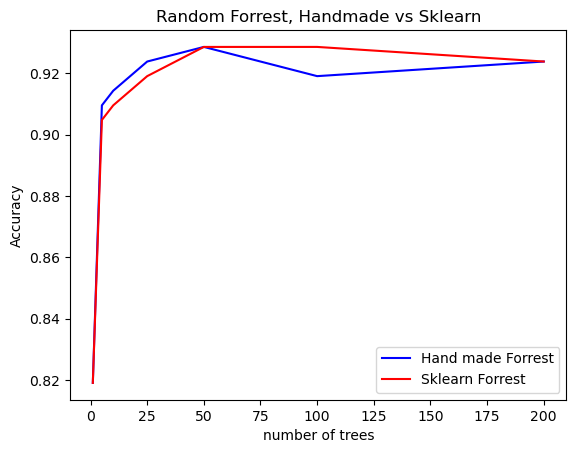

In [5]:
#2.d.
B = [1,5,10,25,50,100,200]
handmade_list = []
sklearn_list = []
for i in B:
    frac, acc, trees = bootstrap(i, X_train, y_train, X_test, y_test)
    all_preds = np.array([tree.predict(X_test) for tree in trees])
    majority_vote = np.mean(all_preds, axis=0) > 0.5
    ensemble_acc = accuracy_score(y_test, majority_vote)
    individual_accs = [tree.score(X_test, y_test) for tree in trees]
    handmade_list.append(ensemble_acc)

    clf = RandomForestClassifier(n_estimators=i, random_state=66)
    clf.fit(X_train,y_train)
    sklearn_list.append(clf.score(X_test, y_test))

    print(f'When number of trees is {i}')
    print(f'Individual tree accuracies: {["{:.1%}".format(a) for a in individual_accs]}')
    print(f'Mean individual accuracy:   {np.mean(individual_accs):.1%}')
    print(f'Best individual accuracy:   {np.max(individual_accs):.1%}')
    print(f'Ensemble (majority vote):   {ensemble_acc:.1%}')
    print('')

fig, ax = plt.subplots()
ax.plot(np.array(B), np.array(handmade_list),c='b',label='Hand made Forrest')
ax.plot(np.array(B), np.array(sklearn_list),c='r',label='Sklearn Forrest')
plt.legend()
plt.title('Random Forrest, Handmade vs Sklearn')
plt.ylabel('Accuracy')
plt.xlabel('number of trees')
plt.show()

2.d 

Give or take a few percentage points since we only go up to 200 different trees, but it mostly looks like these two methods agree. Though if we're to take the data at face value without accounting for any statistical flucuations, it looks like the handmade did better with fewer trees, while the sklearn did better with more trees (past a 100). 

2.e
i: The term that is reduced is the second term (1-p) * (σ^2)/B. Since it has the B term in the denominator, the whole term will decrease when B increases. 
ii: The 'sqrt' term is meant to cause the random tree to choose a random subset of the total features for each split. This increases the randomness of making the decision trees, and thus decreases unintended correlations between features from developing. P here in the equation is pairwise correlation, so this extra bit of randomness will directly decrease p and stop that first term from growing too much. 
iii: The accuracy ensemble starts plateuing rather than increasing to 100% because after a certain point you reach the best trained model from the training data but there will be outliers in the testing data that won't perfectly match up with that model. Random Forrest has checks for overfitting by the randomly selected features choice and majority vote among the different trees, so it won't decrease the testing accuracy. However, there will just be some data points that by random chance can't be easily put in their correct cateogories since there is some overlap between the two data sets, so no matter how many new trees we add, the overall averaging of all of them won't allow the model to get at these outliers and correctly include them. So the test accuracy can't increase anymore than this.

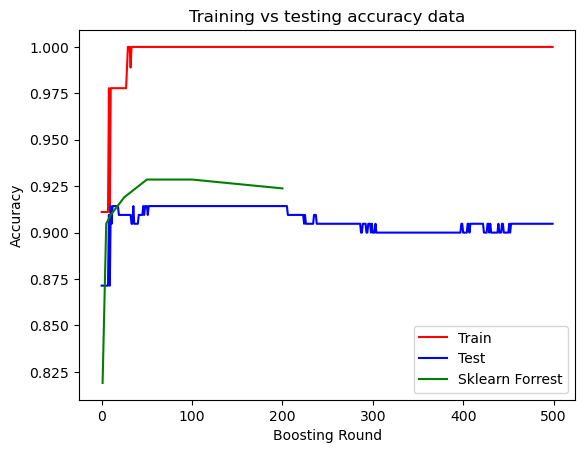

In [6]:
#3.a 
from sklearn.ensemble import GradientBoostingClassifier
boo = GradientBoostingClassifier(n_estimators=500, max_depth=3, learning_rate=0.1, random_state=10)
boo.fit(X_train, y_train)
gb_test_accs = []
gb_train_accs = []
for y_pred in boo.staged_predict(X_test):
    gb_test_accs.append(accuracy_score(y_test, y_pred))
# 3. Also do the same for the training set (staged_predict(X_train))
for y_pred in boo.staged_predict(X_train):
    gb_train_accs.append(accuracy_score(y_train, y_pred))

train_iteration_number = np.arange(len(gb_train_accs))
test_iteration_number = np.arange(len(gb_test_accs))
fig, ax = plt.subplots()
ax.plot(train_iteration_number, gb_train_accs, c='r',label='Train')
ax.plot(test_iteration_number, gb_test_accs, c='b',label='Test')
ax.plot(np.array(B), np.array(sklearn_list),c='g',label='Sklearn Forrest')
ax.set_title("Training vs testing accuracy data")
plt.ylabel('Accuracy')
plt.xlabel('Boosting Round')
plt.legend()
plt.show()

3.a.
The test boosting does start decreasing. It definitely gets worse part boosting round 200, though you could argue it sputters a bit after 10 or 20 rounds of boosting. 

3.b. 

I put the Sklearn random forrest in there as requested, although it doesn't go to the 500 boosting rounds. It also looks like it does decrease a little bit, though not as much as the test accuracy for the boosting. Although, I do have to say that the boosting does look like it plateaus with this data set, which is odd as I know it didn't do that with the circles one in the breakout session with it. Anyway to the actual question, boosting leads to overfitting because that method focuses on continuously making corrections to the same model and data over and over again. After some point you're just making corrections based on the noise rather than the actual data, leading to overfitting. On the otherhand, Random Forrest keeps looking at new bits of the data over many trees and averaging it all out to get a good model for the data rather than fitting to the noise, so overfitting is essentially impossible. 

3.c
The number of steps taken by the Boosting is our n_estimators or the number of times you boost the tree, and the Neural Network each step is the Epoch which it updates its neurons. The learning rate appears in both, and that is just how far each step they take along the negative gradient as boosting updates the decision tree and the neural network updates it neuron layers. The overfitting problem comes to both of them as continued updates give diminishing returns to the testing accuracy, as each new update starts fitting the model to account for the training data's noise rather than the actual signal. 

In [1]:
#4.a
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc

#Generate ising data. 

def ising_monte_carlo(L, T, n_steps=5000, rng=None):
    """Metropolis Monte Carlo for 2D Ising model."""
    if rng is None:
        rng = np.random.default_rng()
    spins = np.random.default_rng().choice([-1, 1], size=(L, L))
    for step in range(n_steps):
        i, j = np.random.default_rng().integers(0, L, size=2)
        neighbors = (
            spins[(i+1) % L, j] + spins[(i-1) % L, j] +
            spins[i, (j+1) % L] + spins[i, (j-1) % L]
        )
        dE = 2 * spins[i, j] * neighbors
        if dE <= 0 or np.random.default_rng().random() < np.exp(-dE / T):
            spins[i, j] *= -1
    return spins

def generate_ising_dataset(L=10, n_samples_per_phase=500, n_mc_steps=10000, rng=None):
    """Generate labeled Ising configurations: ordered (0) vs disordered (1)."""
    if rng is None:
        rng = np.random.default_rng()
    T_c = 2.269
    T_low = np.random.default_rng().uniform(1.0, 1.8, size=n_samples_per_phase)
    T_high = np.random.default_rng().uniform(2.8, 4.0, size=n_samples_per_phase)
    
    configs, labels, temps = [], [], []
    for T in T_low:
        spins = ising_monte_carlo(L, T, n_steps=n_mc_steps, rng=np.random.default_rng())
        configs.append(spins.flatten()); labels.append(0); temps.append(T)
    for T in T_high:
        spins = ising_monte_carlo(L, T, n_steps=n_mc_steps, rng=np.random.default_rng())
        configs.append(spins.flatten()); labels.append(1); temps.append(T)
    
    X = np.array(configs, dtype=np.float32)
    y = np.array(labels, dtype=np.float32)
    T_arr = np.array(temps)
    idx = np.random.permutation(len(y))
    return X[idx], y[idx], T_arr[idx]



In [2]:
X_ising, y_ising, T_ising = generate_ising_dataset(
    L=10, n_samples_per_phase=400, n_mc_steps=1000, rng=0
)
X_tr, X_te, y_tr, y_te, T_tr, T_te = train_test_split(
    X_ising, y_ising, T_ising, test_size=0.3, random_state=0, stratify=y_ising
)


In [3]:
#Logistic Regression
import time
start1 = time.time()
clf1 = LogisticRegression(max_iter=1000, random_state=0).fit(X_tr, y_tr)
end1 = time.time()
train_time1 = end1 - start1
y_pred1 = clf1.predict(X_te)
accuracy1 = clf1.score(X_te,y_te)

y_prob1 = clf1.predict_proba(X_te)[:, 1]
fpr1, tpr1, thresholds1 = roc_curve(y_te, y_prob1)
roc_auc1 = auc(fpr1, tpr1)

In [4]:
#k-Nearest Neighbor. 
from sklearn.neighbors import KNeighborsClassifier
clf2 = KNeighborsClassifier(n_neighbors=5)
start2 = time.time()
clf2.fit(X_tr, y_tr)
end2 = time.time()
train_time2 = end2 - start2
accuracy2 = clf2.score(X_te,y_te)

y_prob2 = clf2.predict_proba(X_te)[:, 1]
fpr2, tpr2, _ = roc_curve(y_te, y_prob2)
roc_auc2 = auc(fpr2, tpr2)

In [5]:
#Random Forrest
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings

clf3 = DecisionTreeClassifier(max_depth=5, random_state=0)
start3 = time.time()
clf3.fit(X_tr, y_tr)
end3 = time.time()
train_time3 = end3 - start3
accuracy3 = clf3.score(X_te, y_te)
y_prob3 = clf3.predict_proba(X_te)[:, 1]
fpr3, tpr3, _ = roc_curve(y_te, y_prob3)
roc_auc3 = auc(fpr3, tpr3)

clf4 = RandomForestClassifier(n_estimators=200, random_state=0)
start4 = time.time()
clf4.fit(X_tr,y_tr)
end4 = time.time()
train_time4 = end4 - start4
accuracy4 = clf4.score(X_te, y_te)
y_prob4 = clf4.predict_proba(X_te)[:, 1]
fpr4, tpr4, _ = roc_curve(y_te, y_prob4)
roc_auc4 = auc(fpr4, tpr4)


In [6]:
#Boosting
from sklearn.ensemble import GradientBoostingClassifier
clf5 = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3)
start5 = time.time()
clf5.fit(X_tr,y_tr)
end5 = time.time()
train_time5 = end5 - start5
accuracy5 = clf5.score(X_te, y_te)
y_prob5 = clf5.predict_proba(X_te)[:, 1]
fpr5, tpr5, _ = roc_curve(y_te, y_prob5)
roc_auc5 = auc(fpr5, tpr5)


In [7]:
#Neural Network
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#Need to make this 10 output neurons, 128 neurons for hidden layer, and ReLU activation function
class FlexNet(nn.Module):
    """
    Flexible feedforward network.
    
    hidden_sizes: list of ints, e.g. [32, 16] for 2 hidden layers
    activation: 'sigmoid', 'relu', or 'tanh'
    """
    def __init__(self, input_dim, hidden_sizes, activation='relu'):
        super().__init__()
        
        act_map = {'sigmoid': nn.Sigmoid, 'relu': nn.ReLU, 'tanh': nn.Tanh}
        act_fn = act_map[activation]
        
        layers = []
        prev_dim = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(act_fn())
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 2))
        #layers.append(nn.Sigmoid())  # output probability
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze(-1)

def train_pytorch(model, train_loader, test_loader, lr=0.1, n_epochs=100, verbose=True):
    """
    Train a PyTorch model and track train/test loss.
    """
    criterion = nn.CrossEntropyLoss()  # binary cross-entropy — same loss as Day 2
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    test_losses = []
    
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        
        for X_batch, y_batch in train_loader:

            X_batch = (X_batch.reshape(-1,100)).to(device)
            y_batch = y_batch.to(device)

            # forward
            y_pred = model(X_batch)
            
            
            loss = criterion(y_pred, (y_batch.to(torch.long)))
            
            # backward (automatic!)
            optimizer.zero_grad()
            loss.backward()
            
            # update
            optimizer.step()
            
            epoch_loss += loss.item()
            n_batches += 1
        
        train_losses.append(epoch_loss / n_batches)
        
        # evaluate on test set
        model.eval()
        with torch.no_grad():
            for Xb, yb in test_loader:
                X_test, y_test = (Xb.reshape(-1,100)).to(device), yb.to(device)
                y_pred_test = model(X_test)
                
                test_loss = criterion(y_pred_test, (y_test.to(torch.long))).item()
                test_losses.append(test_loss)
                
        if verbose and epoch % 10 == 0:
            acc = (np.mean(((torch.argmax(y_pred_test,axis=-1)) == y_test).numpy())).item()
            #acc = (np.mean((y_pred_test == y_test).numpy())).item()
            #print(y_pred_test)
            #print(y_test)
            print(f"  epoch {epoch:4d}  train_loss={train_losses[-1]:.4f}  "
                  f"test_loss={test_loss:.4f}  test_acc={acc:.2%}")
        
    return train_losses, test_losses

In [9]:
X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32).to(device)
X_te_t = torch.tensor(X_te, dtype=torch.float32).to(device)
y_te_t = torch.tensor(y_te, dtype=torch.float32).to(device)

dataset_train = TensorDataset(torch.from_numpy(X_tr).float(), torch.from_numpy(y_tr))
train_loader = DataLoader(dataset_train, batch_size=20, shuffle=True)
dataset_test = TensorDataset(torch.from_numpy(X_te).float(), torch.from_numpy(y_te))
test_loader = DataLoader(dataset_test, batch_size=20, shuffle=False)


240


In [10]:

net_deep_2 = FlexNet(100, [64, 32], activation='relu').to(device)
start6 = time.time()
train_losses_deep_np2, test_losses_deep_np2 = train_pytorch(
    net_deep_2, train_loader, test_loader, lr=0.01, n_epochs=150
)
end6 = time.time()
train_time6 = end6 - start6

  epoch    0  train_loss=0.5678  test_loss=0.4301  test_acc=90.00%
  epoch   10  train_loss=0.0074  test_loss=0.5421  test_acc=90.00%
  epoch   20  train_loss=0.0001  test_loss=0.6873  test_acc=90.00%
  epoch   30  train_loss=0.0000  test_loss=0.7387  test_acc=90.00%
  epoch   40  train_loss=0.0000  test_loss=0.7773  test_acc=90.00%
  epoch   50  train_loss=0.0000  test_loss=0.8037  test_acc=90.00%
  epoch   60  train_loss=0.0000  test_loss=0.8237  test_acc=90.00%
  epoch   70  train_loss=0.0000  test_loss=0.8419  test_acc=90.00%
  epoch   80  train_loss=0.0000  test_loss=0.8597  test_acc=90.00%
  epoch   90  train_loss=0.0000  test_loss=0.8748  test_acc=90.00%
  epoch  100  train_loss=0.0000  test_loss=0.8882  test_acc=90.00%
  epoch  110  train_loss=0.0000  test_loss=0.8997  test_acc=90.00%
  epoch  120  train_loss=0.0000  test_loss=0.9125  test_acc=90.00%
  epoch  130  train_loss=0.0000  test_loss=0.9231  test_acc=90.00%
  epoch  140  train_loss=0.0000  test_loss=0.9328  test_acc=90

In [21]:
import awkward as ak
y_true6 = []
y_pred6 = []
for Xb, yb in test_loader:
    X_test, y_test = (Xb.reshape(-1,100)).to(device), yb.to(device)
    y_pred_test = net_deep_2(X_test)
    y_true6.append(y_test.detach().numpy())
    y_pred6.append((torch.argmax(y_pred_test,axis=-1)).detach().numpy())

y_true6 = ak.flatten(np.array(y_true6))
y_pred6 = ak.flatten(np.array(y_pred6))
accuracy6 = np.mean(y_pred6 == y_true6)

In [19]:
fpr6, tpr6, _ = roc_curve(y_true6, y_pred6)
roc_auc6 = auc(fpr6, tpr6)
print(roc_auc6)

0.8416666666666666


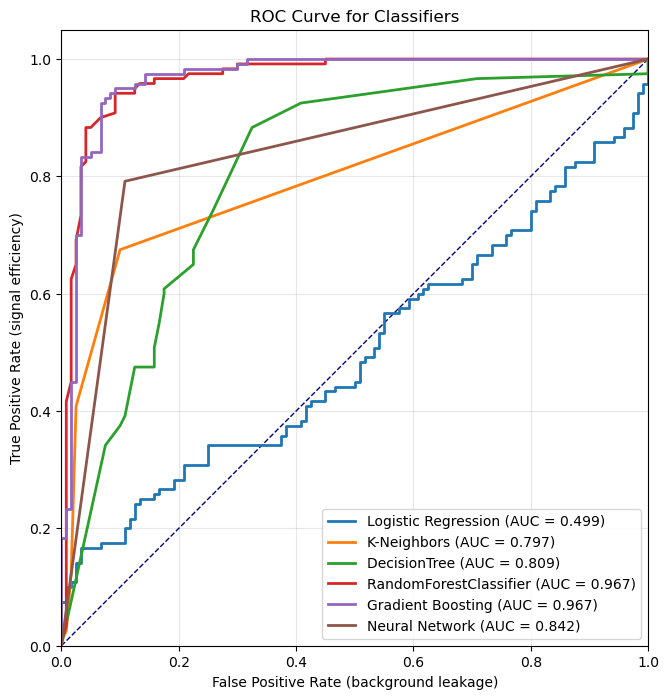

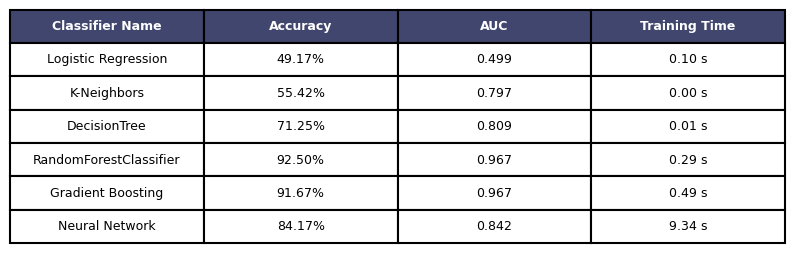

In [28]:
#4.b
import numpy as np
import matplotlib.pyplot as plt
fig_roc, ax_roc = plt.subplots(figsize=(8, 8))

table_data = []
table_data.append(["Logistic Regression", f"{accuracy1:.2%}", f"{roc_auc1:.3f}", f"{train_time1:.2f} s"])
table_data.append(["K-Neighbors", f"{accuracy2:.2%}", f"{roc_auc2:.3f}", f"{train_time2:.2f} s"])
table_data.append(["DecisionTree", f"{accuracy3:.2%}", f"{roc_auc3:.3f}", f"{train_time3:.2f} s"])
table_data.append(["RandomForestClassifier", f"{accuracy4:.2%}", f"{roc_auc4:.3f}", f"{train_time4:.2f} s"])
table_data.append(["Gradient Boosting", f"{accuracy5:.2%}", f"{roc_auc5:.3f}", f"{train_time5:.2f} s"])
table_data.append(["Neural Network", f"{accuracy6:.2%}", f"{roc_auc6:.3f}", f"{train_time6:.2f} s"])

ax_roc.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--') #random guess line!
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate (background leakage)')
ax_roc.set_ylabel('True Positive Rate (signal efficiency)')
ax_roc.set_title('ROC Curve for Classifiers')
ax_roc.set_aspect('equal')
ax_roc.grid(alpha=0.3)

ax_roc.plot(fpr1, tpr1, lw=2, label=f'{"Logistic Regression"} (AUC = {roc_auc1:.3f})')
ax_roc.plot(fpr2, tpr2, lw=2, label=f'{"K-Neighbors"} (AUC = {roc_auc2:.3f})')
ax_roc.plot(fpr3, tpr3, lw=2, label=f'{"DecisionTree"} (AUC = {roc_auc3:.3f})')
ax_roc.plot(fpr4, tpr4, lw=2, label=f'{"RandomForestClassifier"} (AUC = {roc_auc4:.3f})')
ax_roc.plot(fpr5, tpr5, lw=2, label=f'{"Gradient Boosting"} (AUC = {roc_auc5:.3f})')
ax_roc.plot(fpr6, tpr6, lw=2, label=f'{"Neural Network"} (AUC = {roc_auc6:.3f})')
ax_roc.legend(loc="lower right")
fig_table, ax_table = plt.subplots(figsize=(10, 3)) # Separatjion
ax_table.axis('off')

column_labels = ["Classifier Name", "Accuracy", "AUC", "Training Time"]
table = ax_table.table(
    cellText=table_data,
    colLabels=column_labels,
    loc='center',
    cellLoc='center'
)

# Table Styling
for (row, col), cell in table.get_celld().items():
    cell.set_linewidth(1.5)
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#40466E')
    else:
        cell.set_facecolor('white')

table.scale(1, 2)
plt.show()


In [39]:
def add_engineered_features(X, L):
    n_samples = X.shape[0]
    engineered = []
    for i in range(n_samples):
        lattice = X[i].reshape(L,L)
        m = np.mean(lattice)
        m_abs = np.abs(m)
        right_neighbors = np.roll(lattice, -1, axis=1)
        bottom_neighbors = np.roll(lattice, -1, axis=0)
        interactions = (lattice * right_neighbors) + (lattice * bottom_neighbors)
        energy = -np.sum(interactions) / (2 * L**2)
        engineered.append([m, m_abs, energy])
    X_extra = np.array(engineered)
    return np.hstack((X, X_extra))

L = 10
X_tr_ef = add_engineered_features(X_tr, L)
X_te_ef = add_engineered_features(X_te, L)




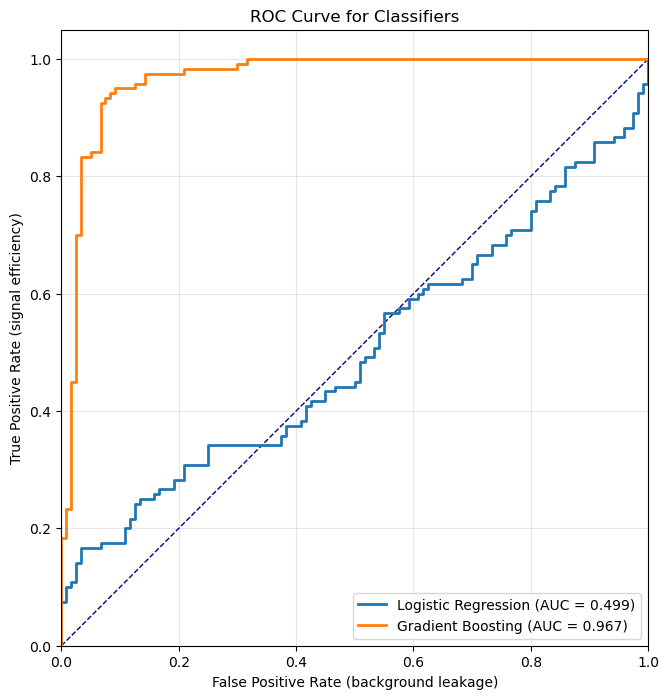

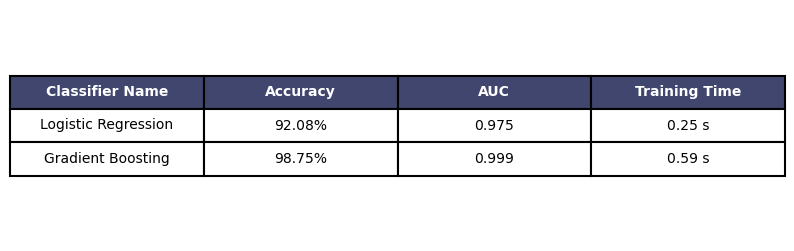

In [74]:
#Logistic Regression
nstart1 = time.time()
nclf1 = LogisticRegression(max_iter=1000, random_state=0).fit(X_tr_ef, y_tr)
nend1 = time.time()
ntrain_time1 = nend1 - nstart1
ny_pred1 = nclf1.predict(X_te_ef)
naccuracy1 = nclf1.score(X_te_ef,y_te)

ny_prob1 = nclf1.predict_proba(X_te_ef)[:, 1]
nfpr1, ntpr1, thresholds1 = roc_curve(y_te, ny_prob1)
nroc_auc1 = auc(nfpr1, ntpr1)

#Boosting
nstart5 = time.time()
clf5.fit(X_tr_ef,y_tr)
nend5 = time.time()
ntrain_time5 = nend5 - nstart5
naccuracy5 = clf5.score(X_te_ef, y_te)
ny_prob5 = clf5.predict_proba(X_te_ef)[:, 1]
nfpr5, ntpr5, _ = roc_curve(y_te, ny_prob5)
nroc_auc5 = auc(nfpr5, ntpr5)

fig_roc, ax_roc = plt.subplots(figsize=(8, 8))

table_data = []
table_data.append(["Logistic Regression", f"{naccuracy1:.2%}", f"{nroc_auc1:.3f}", f"{ntrain_time1:.2f} s"])
table_data.append(["Gradient Boosting", f"{naccuracy5:.2%}", f"{nroc_auc5:.3f}", f"{ntrain_time5:.2f} s"])

ax_roc.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--') #random guess line!
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate (background leakage)')
ax_roc.set_ylabel('True Positive Rate (signal efficiency)')
ax_roc.set_title('ROC Curve for Classifiers')
ax_roc.set_aspect('equal')
ax_roc.grid(alpha=0.3)

ax_roc.plot(fpr1, tpr1, lw=2, label=f'{"Logistic Regression"} (AUC = {roc_auc1:.3f})')

ax_roc.plot(fpr5, tpr5, lw=2, label=f'{"Gradient Boosting"} (AUC = {roc_auc5:.3f})')

ax_roc.legend(loc="lower right")
fig_table, ax_table = plt.subplots(figsize=(10, 3)) # Separatjion
ax_table.axis('off')

column_labels = ["Classifier Name", "Accuracy", "AUC", "Training Time"]
table = ax_table.table(
    cellText=table_data,
    colLabels=column_labels,
    loc='center',
    cellLoc='center'
)

# Table Styling
for (row, col), cell in table.get_celld().items():
    cell.set_linewidth(1.5)
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#40466E')
    else:
        cell.set_facecolor('white')

table.scale(1, 2)
plt.show()


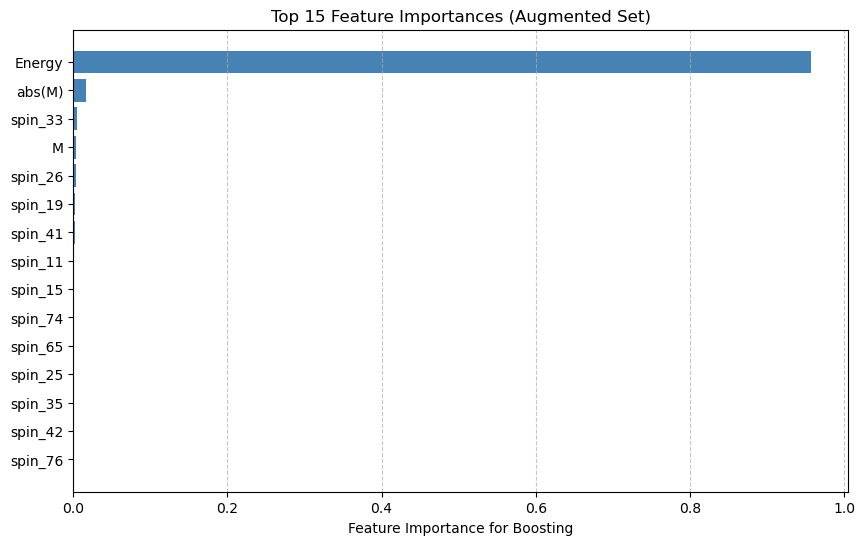

In [76]:
#Getting the features importance bar chart

feature_names = [f'spin_{i}' for i in range(100)] + ['M', 'abs(M)', 'Energy']

importances = clf5.feature_importances_
top_k = 15
top_idx = np.argsort(importances)[::-1][:top_k]

plt.figure(figsize=(10, 6))
plt.barh(range(top_k), importances[top_idx], color='steelblue')
plt.yticks(range(top_k), [feature_names[i] for i in top_idx])
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance for Boosting')
plt.title('Top 15 Feature Importances (Augmented Set)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()



4.C
So we saw that Nearest-Neighbor Energy was the max, and by the bar graph it was by A LOT. The seccond being the Absolute Magnetization. Which just shows that the Boosting didn't really learn any features of the data, but instead just used the absolute magnetization and Nearest-Neighbor Energy to sort everything. 

And comparing to what they got in part a, the logistic regression and Gradient boosting did MUCH better with the new engineered features, getting better accuracy and AUC. However, they did get slightly less good training time. Gradient Boosting nearly got it 100% perfect actually with these new features. 

4.d.

i. The model that did best on using the spin features was the Random Forest, with both the highest accuracy and AUC, and still a pretty low training time compared to its nearest rivals. On the Engineered Features, Gradient Boosting did the best by fair as it nearly had a 99% accuracy rate and the highest AUC out of any trained model. 

ii. It seems like Engineering features could be a really good idea to make models, as giving a model a feature that you know could sort the data would give it the best chance of successfully sorting the data. So if your goal is getting a really accurate model, engineering features in is the way to go. However, if you were trying to find new features to sort the data through, it wouldn't make any sense giving engineered features to the model because that is all the model is then going to use since it works so well. 

iii. We would choose random forest classifier as the default analysis method, because it has the highest accuracy rate without adding engineered features and runs faster than gradient boosting classifier. This means it is less computational expensive, and it will save a tons of time while analyzing huge amount of data (e.g. LHCB data set). As for the case if we had a smaller dataset, Random Forest does not overfit the data due to the implementation majority vote and randomness baked into the model. So it would be able to do a good job sorting the data in a fast time, but also more likely to capture the desired signal. 